# PRIMERA CARGA Y ESTUDIO DE DATOS

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_customers=pd.read_csv('./resources/olist_customers_dataset.csv').drop_duplicates()
df_items=pd.read_csv('./resources/olist_order_items_dataset.csv').drop_duplicates()
df_payments=pd.read_csv('./resources/olist_order_payments_dataset.csv').drop_duplicates()
df_reviews=pd.read_csv('./resources/olist_order_reviews_dataset.csv').drop_duplicates()
df_orders=pd.read_csv('./resources/olist_orders_dataset.csv').drop_duplicates()
df_product_category_translation=pd.read_csv('./resources/olist_product_category_name_translation.csv').drop_duplicates()
df_products=pd.read_csv('./resources/olist_products_dataset.csv').drop_duplicates()
df_sellers=pd.read_csv('./resources/olist_sellers_dataset.csv').drop_duplicates()



#  Creacion de traducciones nuevos productos


In [5]:

print(pd.merge(pd.DataFrame(df_products['product_category_name'].unique()),pd.DataFrame(df_product_category_translation['product_category_name'].unique())
      ,how='outer',indicator=True).query('_merge== "left_only"').drop(columns=['_merge']))
# Añadimos los productos a la tabla de traducción
df_product_category_translation.loc[len(df_product_category_translation)] = ["pc_gamer", "pc_gamer"]
df_product_category_translation.loc[len(df_product_category_translation)] = ["portateis_cozinha_e_preparadores_de_alimentos", "kitchenware_and_food_preparers"]



                                                0
60                                       pc_gamer
65  portateis_cozinha_e_preparadores_de_alimentos
73                                            NaN


# Inserccion de columna product category name english en producto


In [6]:
df_products=pd.merge(df_products,df_product_category_translation,on='product_category_name')
df_products.rename(columns={'product_category_name':'product_category_name_pt'},inplace=True)

# Eliminacion de columnas inecesarias en products y eliminacion df de traducciones


In [7]:
df_products.insert(2,"product_category_name_en",df_products.pop("product_category_name_english"))
df_products.pop('product_name_lenght')
df_products.pop('product_description_lenght')
del df_product_category_translation
df_products

,product_id,product_category_name_pt,product_category_name_en,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...
32336,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,2.0,12300.0,40.0,40.0,40.0
32337,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,1.0,1700.0,16.0,19.0,16.0
32338,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,1.0,1400.0,27.0,7.0,27.0
32339,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,2.0,700.0,31.0,13.0,20.0


#  Creacion tabla geolocation y eliminar columnas redundantes(customer/seller_city/state)

In [8]:

df_loc_customer=df_customers.loc[:,['customer_zip_code_prefix','customer_city','customer_state'
                             ]].rename(columns={'customer_zip_code_prefix':'zip_code_prefix','customer_city':'city','customer_state':'state'})
# df_customers.drop(['customer_city','customer_state'],inplace=True,axis=1)
df_loc_sellers=df_sellers.loc[:,['seller_zip_code_prefix','seller_city','seller_state'
                             ]].rename(columns={'seller_zip_code_prefix':'zip_code_prefix','seller_city':'city','seller_state':'state'})
# df_sellers.drop(['seller_city','seller_state'],inplace=True,axis=1)
df_geolocation=pd.concat([df_loc_customer,df_loc_sellers]).drop_duplicates(subset=['zip_code_prefix'])

# Cambiamos a tipo fecha

In [9]:

df_orders['order_delivered_carrier_date']=pd.to_datetime(df_orders['order_delivered_carrier_date'])
df_orders['order_delivered_customer_date']=pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date']=pd.to_datetime(df_orders['order_estimated_delivery_date'])
df_orders['order_purchase_timestamp']=pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_approved_at']=pd.to_datetime(df_orders['order_approved_at'])
df_items['shipping_limit_date']=pd.to_datetime(df_items['shipping_limit_date'])
df_reviews['review_creation_date']=pd.to_datetime(df_reviews['review_creation_date'])
df_reviews['review_answer_timestamp']=pd.to_datetime(df_reviews['review_answer_timestamp'])

# PROYECTO DE EQUIPO

## Ejercicio 1


### Agrupar por state

In [10]:
df_customers_unique = df_customers
df_customers_unique = df_customers_unique.drop_duplicates(subset='customer_unique_id',ignore_index=True)
 
df_state_group = df_customers_unique.groupby(['customer_state']).customer_unique_id.count().sort_values(ascending=False)
df_state_group

customer_state
SP    40295
RJ    12377
MG    11255
RS     5277
PR     4882
SC     3529
BA     3276
DF     2073
ES     1963
GO     1951
PE     1604
CE     1311
PA      949
MT      875
MA      725
MS      693
PB      519
PI      482
RN      474
AL      401
SE      341
TO      273
RO      239
AM      143
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64

### Agrupar por ciudad

In [11]:
df_city_state_group = df_customers_unique.groupby(['customer_city','customer_state'], as_index=False).customer_unique_id.count().sort_values('customer_unique_id', ascending=False).reset_index(drop=True)
 
df_city_state_group= df_city_state_group.rename(columns={'customer_unique_id':'customer_number'})
 
df_city_state_group

,customer_city,customer_state,customer_number
0,sao paulo,SP,14971
1,rio de janeiro,RJ,6611
2,belo horizonte,MG,2671
3,brasilia,DF,2066
4,curitiba,PR,1462
...,...,...,...
4304,pinhotiba,MG,1
4305,pinto bandeira,RS,1
4306,pio ix,PI,1
4307,pio xii,MA,1


# Visualizacion añadir fecha al df

In [12]:
df_customer_order=pd.merge(df_customers_unique,df_orders[['customer_id','order_purchase_timestamp']],on='customer_id')
df_customer_order

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_purchase_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,2017-05-16 15:05:35
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,2018-01-12 20:48:24
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,2018-05-19 16:07:45
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,2018-03-13 16:06:38
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,2018-07-29 09:51:30
...,...,...,...,...,...,...
96091,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,2018-04-07 15:48:17
96092,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,2018-04-04 08:20:22
96093,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,2018-04-08 20:11:50
96094,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,2017-11-03 21:08:33


# Ejercicio 2


In [13]:
df_city_state_group_orders = df_customers.groupby(['customer_city','customer_state'], as_index=False).customer_id.count().sort_values('customer_id', ascending=False).reset_index(drop=True)
df_city_state_group_orders= df_city_state_group_orders.rename(columns={'customer_id':'order_numbers'})
df_city_state_group_orders # type: ignore
df_customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [14]:
#columna numero pedidos
df_city_customer_orders = df_city_state_group
df_city_customer_orders['order_number'] = df_city_state_group_orders['order_numbers']
df_city_customer_orders

,customer_city,customer_state,customer_number,order_number
0,sao paulo,SP,14971,15540
1,rio de janeiro,RJ,6611,6882
2,belo horizonte,MG,2671,2773
3,brasilia,DF,2066,2131
4,curitiba,PR,1462,1521
...,...,...,...,...
4304,pinhotiba,MG,1,1
4305,pinto bandeira,RS,1,1
4306,pio ix,PI,1,1
4307,pio xii,MA,1,1


3. **Calcula**, el nº de pedidos que llegan tarde por ciudad, el porcentaje que representa respecto al total de pedidos por ciudad, 
junto con el tiempo medio de dias que se pasan de fecha, queremos que a la hora de representar esta falla salga ya autodiagnosticada 
con la razon mas probable del problema. (Analiza el dataset)

In [15]:
# Calculamos diferencaia de fecha entre estimado y entregado
df_orders['date_diference'] = df_orders['order_estimated_delivery_date'] - df_orders['order_delivered_customer_date']
# Nos quedamos con las negativas
negative_dates_df = df_orders[df_orders['date_diference'] < pd.Timedelta(0)]

# Mergeamos para asociar un customer_id a cada retraso
df_merge_negative_dates_customers = pd.merge(
    df_customers[['customer_id','customer_city','customer_state']],
    negative_dates_df[['customer_id','date_diference']],
    on='customer_id',
    how='inner'
)

# Contamos el numero de envios retrasados por ciudad
df_city_state_late_group = df_merge_negative_dates_customers.groupby(['customer_city','customer_state'], as_index=False).customer_id.count().sort_values('customer_id', ascending=False).reset_index(drop=True)
df_city_state_late_group= df_city_state_late_group.rename(columns={'customer_id':'orders_late'})

#el porcentaje que representa respecto al total de pedidos por ciudad
df_city_state_late_group['late_orders_respect_total_%'] = ((df_city_state_late_group['orders_late']/df_city_customer_orders['order_number'])*100).round(2)

# Dejamos los valores en valor absoluto
df_merge_negative_dates_customers['date_diference'] = df_merge_negative_dates_customers['date_diference'].abs()

# Sacamos la media por ciudad y estado
df_city_state_late_mean_days_group = df_merge_negative_dates_customers.groupby(['customer_city','customer_state'], as_index=False)['date_diference'].mean().sort_values('date_diference', ascending=False).reset_index(drop=True)
df_city_state_late_mean_days_group = df_city_state_late_mean_days_group.rename(columns={'date_diference':'days_diference_mean'})


df_merge_late_total = pd.merge(
    df_city_state_late_group,
    df_city_state_late_mean_days_group,
    on='customer_city',
    how='inner'
)

# eliminamos customer state de df_city_state_late_mean_days_group porque no se mapea bien y es redundante
df_merge_late_total = df_merge_late_total.drop('customer_state_y', axis=1)
df_merge_late_total= df_merge_late_total.rename(columns={'customer_state_x':'customer_state'})

# Pasamos a float
df_merge_late_total['days_diff_float'] = df_merge_late_total['days_diference_mean'].dt.total_seconds() / 86400
df_merge_late_total['days_diff_float']
df_merge_late_total


,customer_city,customer_state,orders_late,late_orders_respect_total_%,days_diference_mean,days_diff_float
0,sao paulo,SP,942,6.06,6 days 09:28:35.647558386,6.394857
1,rio de janeiro,RJ,780,11.33,12 days 18:35:43.294871794,12.774807
2,salvador,BA,208,7.50,9 days 18:13:16.269230769,9.759216
3,belo horizonte,MG,166,7.79,6 days 19:16:06.216867469,6.802850
4,porto alegre,RS,158,10.39,9 days 19:06:22.715189873,9.796096
...,...,...,...,...,...,...
1354,ampere,PR,1,16.67,0 days 16:37:00,0.692361
1355,vila pereira,MG,1,16.67,1 days 13:52:27,1.578090
1356,vila nova do sul,RS,1,16.67,0 days 09:36:50,0.400579
1357,alcobaca,BA,1,16.67,2 days 06:32:10,2.272338


In [16]:
# Diagnosticar el porque de la 
def diagnose(row):
    delay = row['days_diff_float']                     
    pct = row['late_orders_respect_total_%']          
    late = row['orders_late']                          
    #Reglas de diagnóstico
    if delay > 10:
        return "Retrasos severos: rutas largas o problemas logísticos regionales"
    if pct > 30:
        return "Alta proporción de retrasos: sobrecarga operativa o falta de infraestructura"
    if late > 5 and pct < 20:
        return "Pocos pedidos tardíos pero desviaciones grandes: fallos puntuales de transportista"
    if delay <= 3:
        return "Retraso leve: problemas típicos de última hora o reparto urbano"
    return "Retraso moderado: problemas recurrentes pero no críticos"

In [17]:
df_merge_late_total['diagnosis'] = df_merge_late_total.apply(diagnose, axis=1)
df_merge_late_total = df_merge_late_total.drop('days_diff_float', axis=1)
df_merge_late_total

,customer_city,customer_state,orders_late,late_orders_respect_total_%,days_diference_mean,diagnosis
0,sao paulo,SP,942,6.06,6 days 09:28:35.647558386,Pocos pedidos tardíos pero desviaciones grande...
1,rio de janeiro,RJ,780,11.33,12 days 18:35:43.294871794,Retrasos severos: rutas largas o problemas log...
2,salvador,BA,208,7.50,9 days 18:13:16.269230769,Pocos pedidos tardíos pero desviaciones grande...
3,belo horizonte,MG,166,7.79,6 days 19:16:06.216867469,Pocos pedidos tardíos pero desviaciones grande...
4,porto alegre,RS,158,10.39,9 days 19:06:22.715189873,Pocos pedidos tardíos pero desviaciones grande...
...,...,...,...,...,...,...
1354,ampere,PR,1,16.67,0 days 16:37:00,Retraso leve: problemas típicos de última hora...
1355,vila pereira,MG,1,16.67,1 days 13:52:27,Retraso leve: problemas típicos de última hora...
1356,vila nova do sul,RS,1,16.67,0 days 09:36:50,Retraso leve: problemas típicos de última hora...
1357,alcobaca,BA,1,16.67,2 days 06:32:10,Retraso leve: problemas típicos de última hora...


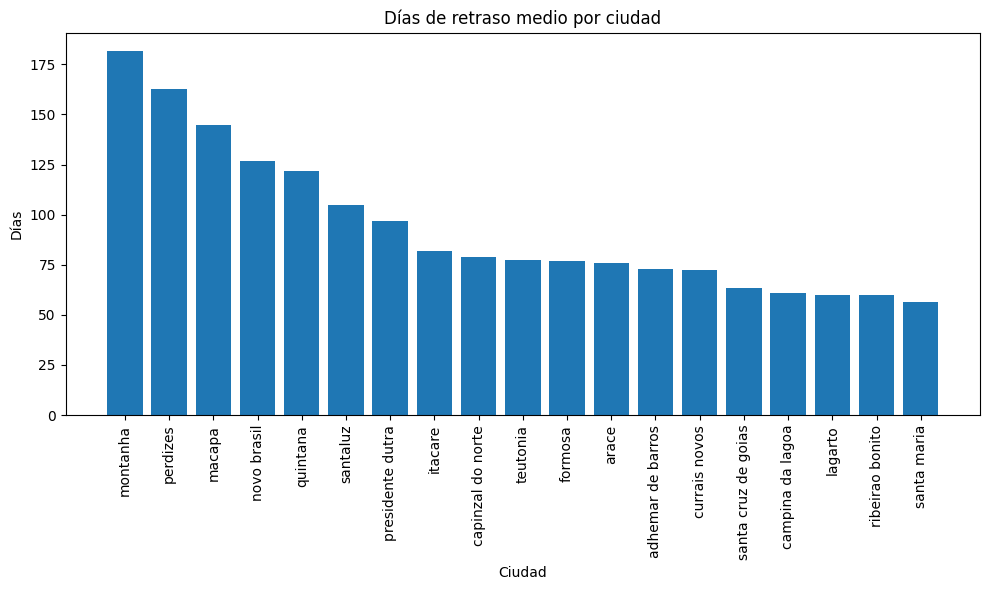

In [18]:
df_merge_late_total['delay_days'] = df_merge_late_total['days_diference_mean'].dt.total_seconds() / 86400
df_sorted = df_merge_late_total.sort_values('delay_days', ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.bar(df_sorted['customer_city'], df_sorted['delay_days'])
plt.xticks(rotation=90)
plt.title("Días de retraso medio por ciudad")
plt.ylabel("Días")
plt.xlabel("Ciudad")
plt.tight_layout()
plt.show()

## 4

In [19]:
df_reviews['review_comment_title'] = df_reviews['review_comment_title'].fillna('No title')
df_reviews['review_comment_message'] = df_reviews['review_comment_message'].fillna('No comment')
df_reviews['review_comment_message'] = df_reviews['review_comment_message'].str.capitalize()
df_reviews['review_comment_title'] = df_reviews['review_comment_title'].str.capitalize()

#pedidos entregados a tiempo
df_orders['date_diference'] = df_orders['order_estimated_delivery_date'] - df_orders['order_delivered_customer_date']
positive_dates_df = df_orders[df_orders['date_diference'] > pd.Timedelta(0)]


# Unimos review score a un customer_id concreto
df_merge_positive_dates_customers = pd.merge(
    positive_dates_df[['customer_id','order_id']],
    df_reviews[['order_id','review_score']],
    on='order_id',
    how='inner'
)
df_merge_positive_dates_customers.drop('order_id',axis=1,inplace=True)
# Unimos para tener valor de state por review
df_merge_reviews_customers = pd.merge(
    df_customers,
    df_merge_positive_dates_customers,
    on='customer_id',
    how='inner'
)
# Recuento de reviews por estado
df_number_review_state= df_merge_reviews_customers.groupby(['customer_state'])['review_score'].count().sort_values(ascending=False).reset_index(name='number_reviews')

#score medio
df_mean_score = df_merge_reviews_customers.groupby('customer_state')['review_score'].mean().sort_values(ascending=False).round(2).reset_index(name='review_score_mean')
df_mean_score

,customer_state,review_score_mean
0,RN,4.40
1,MS,4.37
2,SP,4.33
3,RS,4.31
4,AL,4.31
5,PR,4.31
6,PE,4.30
7,TO,4.29
8,SC,4.29
9,PI,4.29


## EXTRA


In [20]:
#Sacar numero de productos vendidos por su categoría. Agrupado por estado y país. Utilizar pedidos vendidos y entregados.
# df_merge_product_categories_items = pd.merge(
#     df_items,
#     df_products_merge,
#     on='product_id',
#     how='inner'
# )
# df_merge_product_categories_items = df_merge_product_categories_items[['order_id','product_id','product_category_name_english']]
# df_merge_product_categories_items